In [5]:
# Import required libraries for the task
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import yfinance as yf  # For downloading stock data if needed
import talib  # For applying technical analysis indicators
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For better visualizations
import os

In [6]:
# Define the directory where the stock data is stored
data_dir = '../data/yfinance_data/'

# List all the files in the directory
stock_files = os.listdir(data_dir)

# Load each stock's data into a dictionary for easy access
stock_data = {}
for file in stock_files:
    if file.endswith('.csv'):
        stock_symbol = file.split('_')[0]  # Assuming the filename is something like 'AAPL_historic.csv'
        stock_data[stock_symbol] = pd.read_csv(os.path.join(data_dir, file))

# Display the first few rows of one stock (AAPL) as an example
stock_data['AAPL'].head()


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0.0
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0.0
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0.0


In [7]:
# Define a function to calculate technical indicators for the stock data
def calculate_indicators(df):
    # Calculate the 50-day moving average (MA50)
    df['MA50'] = talib.SMA(df['Close'], timeperiod=50)

    # Calculate the 200-day moving average (MA200)
    df['MA200'] = talib.SMA(df['Close'], timeperiod=200)

    # Calculate the Relative Strength Index (RSI)
    df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

    return df

# Apply the function to each stock data in stock_data
for symbol, df in stock_data.items():
    stock_data[symbol] = calculate_indicators(df)

# Display the first few rows of AAPL after applying indicators
stock_data['AAPL'].head()


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,MA50,MA200,RSI
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0,NaN,NaN,NaN
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0,NaN,NaN,NaN
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0.0,NaN,NaN,NaN
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0.0,NaN,NaN,NaN
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0.0,NaN,NaN,NaN


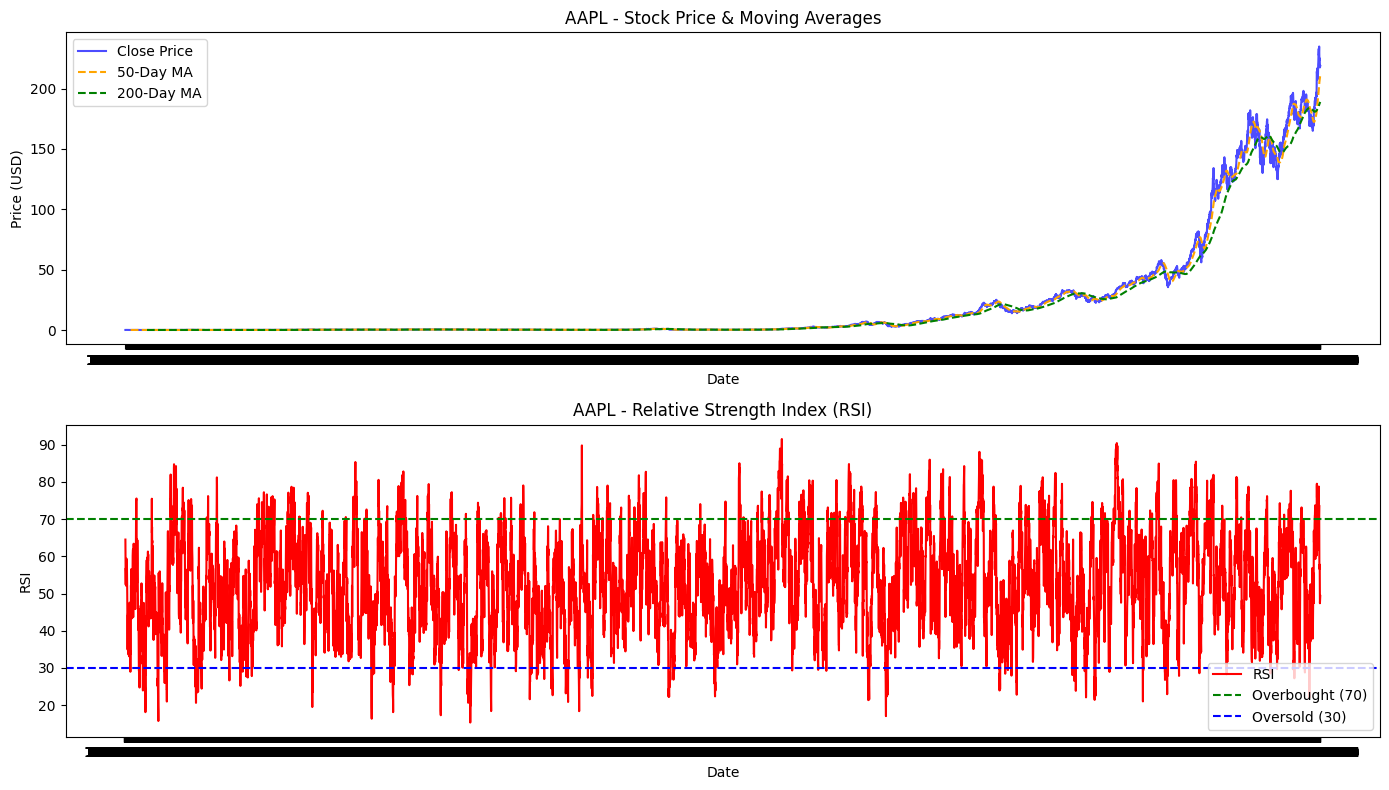

In [8]:
# Function to plot the technical indicators
def plot_technical_indicators(df, symbol):
    # Create a figure and axis
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot the stock price and the moving averages
    axes[0].plot(df['Date'], df['Close'], label='Close Price', color='blue', alpha=0.7)
    axes[0].plot(df['Date'], df['MA50'], label='50-Day MA', color='orange', linestyle='--')
    axes[0].plot(df['Date'], df['MA200'], label='200-Day MA', color='green', linestyle='--')
    axes[0].set_title(f'{symbol} - Stock Price & Moving Averages')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    # Plot the RSI
    axes[1].plot(df['Date'], df['RSI'], label='RSI', color='red')
    axes[1].axhline(70, color='green', linestyle='--', label='Overbought (70)')
    axes[1].axhline(30, color='blue', linestyle='--', label='Oversold (30)')
    axes[1].set_title(f'{symbol} - Relative Strength Index (RSI)')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('RSI')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Plot for AAPL
plot_technical_indicators(stock_data['AAPL'], 'AAPL')


In [9]:
# Calculate daily returns for each stock
stock_data_returns = {}
for symbol, data in stock_data.items():
    data['Daily_Return'] = data['Close'].pct_change() * 100  # Percent change in close price
    stock_data_returns[symbol] = data

# Example for AAPL:
stock_data_returns['AAPL'].head()


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,MA50,MA200,RSI,Daily_Return
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0,NaN,NaN,NaN,NaN
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0,NaN,NaN,NaN,-5.217061
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0.0,NaN,NaN,NaN,-7.339788
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0.0,NaN,NaN,NaN,2.475091
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0.0,NaN,NaN,NaN,2.899246


In [32]:
news_df = pd.read_csv('../data/news_with_sentiment.csv')

# Display the first few rows to ensure it was loaded correctly
news_df.head()

,headline,url,publisher,date,stock,headline_length,sentiment
0,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 13:07:04+00:00,A,120,0.250000
1,Shares of several basic material companies are...,https://www.benzinga.com/wiim/20/06/16213027/s...,Benzinga Newsdesk,2020-06-09 14:52:15+00:00,AA,323,-0.035714
2,Alcoa Seeing Better July Aluminum Shipments Am...,https://www.benzinga.com/news/20/06/16203021/a...,Benzinga Newsdesk,2020-06-08 15:29:29+00:00,AA,129,0.500000
3,Shares of several basic materials companies ar...,https://www.benzinga.com/wiim/20/06/16202370/s...,Benzinga Newsdesk,2020-06-08 14:32:42+00:00,AA,241,0.112879
4,Shares of several basic materials are trading ...,https://www.benzinga.com/wiim/20/06/16183243/s...,Benzinga Newsdesk,2020-06-04 18:46:13+00:00,AA,241,0.106250


In [36]:
# Convert 'Date' in stock data to datetime format
for symbol, data in stock_data_returns.items():
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Convert 'date' in news_df to datetime format
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# Perform the merge again with both 'Date' and 'date' in datetime format
merged_data = pd.DataFrame()
for symbol, data in stock_data_returns.items():
    merged = pd.merge(data[['Date', 'Daily_Return']], news_df[['date', 'sentiment']], left_on='Date', right_on='date', how='inner')
    merged_data = pd.concat([merged_data, merged], axis=0)

# Check the merged data again
merged_data.head()


,Date,Daily_Return,date,sentiment
0,2011-04-28,-0.971004,2011-04-28,0.136364
1,2011-04-29,0.974765,2011-04-29,-0.166667
2,2011-04-29,0.974765,2011-04-29,0.500000
3,2011-05-02,-1.099598,2011-05-02,-0.083333
4,2011-05-06,-0.025960,2011-05-06,0.500000


In [37]:
# Calculate the correlation between daily returns and sentiment scores
correlation = merged_data['Daily_Return'].corr(merged_data['sentiment'])

# Display the correlation
print(f"Correlation between Daily Returns and Sentiment: {correlation:.4f}")


Correlation between Daily Returns and Sentiment: 0.0147


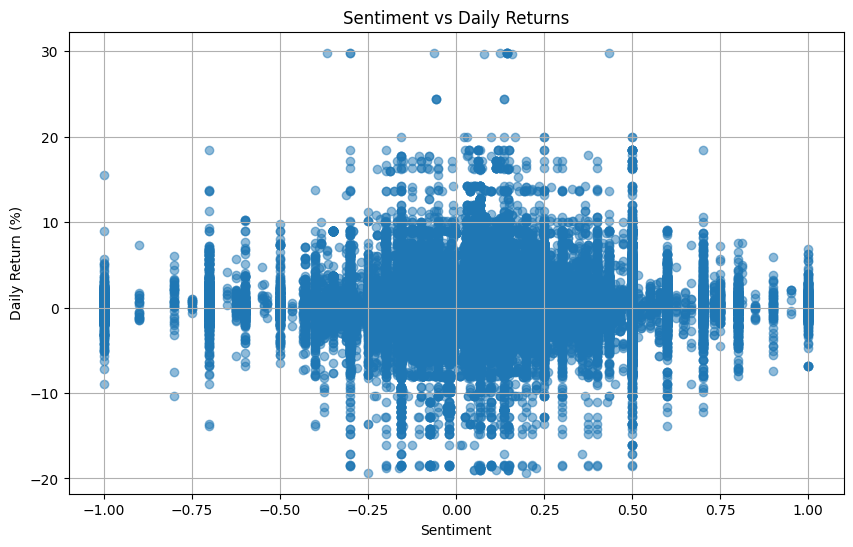

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['sentiment'], merged_data['Daily_Return'], alpha=0.5)
plt.title('Sentiment vs Daily Returns')
plt.xlabel('Sentiment')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()